In [1]:
import os
import glob
import torch
torch.set_default_dtype(torch.double)

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision  
import matplotlib.pyplot as plt
from nflows import flows, distributions, transforms
from nflows.transforms.normalization import ActNorm
from tqdm import tqdm

from src.diffeomorphisms.image.starflow import StarFlowImageDiffeomorphism
from src.diffeomorphisms.image.transform import TransformImageDiffeomorphism
from src.distributions.star_gaussians.multi_inverse_pre_bias_linear_norm_gaussian import MultiInversePreBiasLinearStarNormGaussianDistribution
from src.embedding.hyperbolic_gromov_monge import HyperbolicGromovMongeEmbedding
from src.manifolds.euclidean.image.pullback.standard import StandardPullbackImageEuclidean
from src.manifolds.isometrized_euclidean.image import l2IsometrizedImageEuclidean
from src.training.diffeomorphic_decoder import DiffeomorphicDecoderTraining
from src.training.hyperbolic_gromov_monge_embedding import HyperbolicGromovMongeEmbeddingTraining
from src.training.latent_star_gaussian import LatentStarGaussianTraining
from src.transforms.image.to_vec import ToVecImageTransform
from src.transforms.image.parity_conv.linear_2d import Linear2DParityConvImageTransform
from src.transforms.image.parity_conv.simple_tanh_2d import SimpleTanh2DParityConvImageTransform

from config_loader import load_experiment_config 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# fix seed
torch.manual_seed(31)

# ---- load YAML config ----
CONFIG_PATH = "configs/mnist/three_phases.yaml"
EXPERIMENT_NAME = "mnist_16"       # change this to 'mnist_16', etc.

cfg = load_experiment_config(CONFIG_PATH, EXPERIMENT_NAME)

data_cfg = cfg["data"]
phase_1_cfg = cfg["phase_1"]
phase_2_cfg = cfg["phase_2"]
phase_3_cfg = cfg["phase_3"]

size = data_cfg["size"]
batch_size = data_cfg["batch_size"]

phase_1_training = phase_1_cfg["enabled"]
phase_2_training = phase_2_cfg["enabled"]
phase_3_training = phase_3_cfg["enabled"]

results_folder = os.path.join(
    cfg["base_results_dir"],
    f"{size}x{size}"
)

os.makedirs(results_folder, exist_ok=True)

### Construct data set ###

In [2]:
H = W = size
mnist_mean = cfg["data"]["mnist_mean"]
mnist_var = cfg["data"]["mnist_var"]
train_val_split = cfg["data"]["train_val_split"]
sigma = cfg["data"]["sigma"]

transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((H, W)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((mnist_mean,), (mnist_var,))
])

full_dataset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)

train_size = int(train_val_split * len(full_dataset))
val_size = len(full_dataset) - train_size
data_train, data_val = random_split(full_dataset, [train_size, val_size])


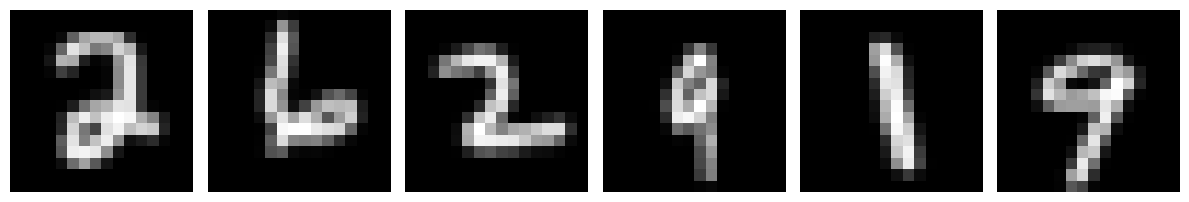

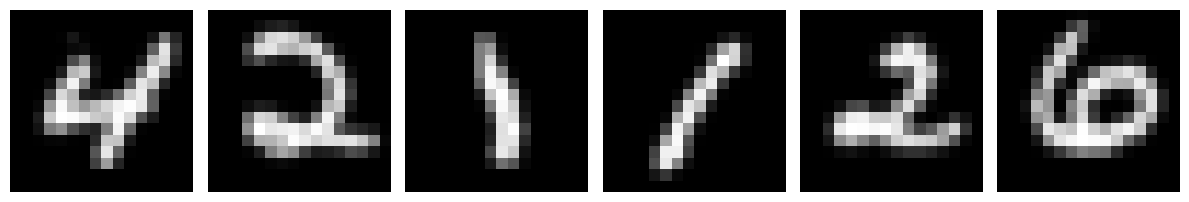

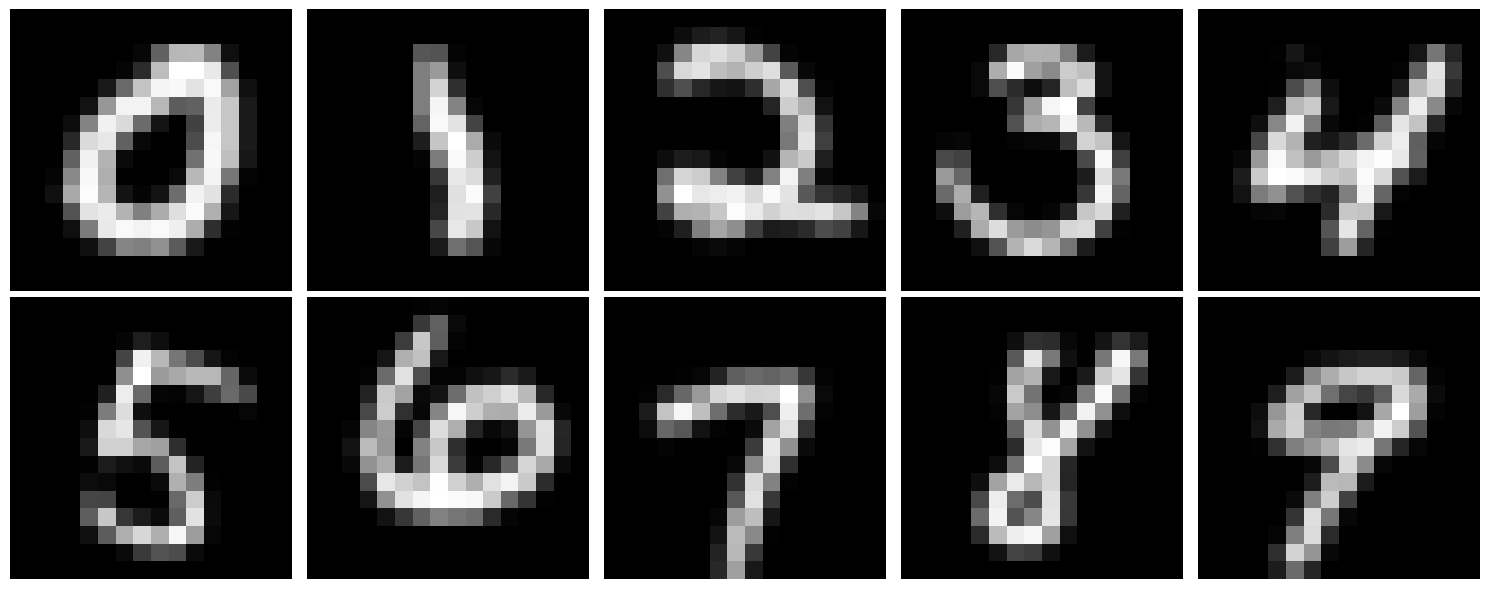

In [3]:
class RandomPairDataset(Dataset):
    def __init__(self, data):
        self.data = data            # shape: N x d
        self.N = data.__len__()

    def __len__(self):
        return self.N  # you can pick another value if you wish

    def __getitem__(self, idx):
        # x: deterministic sample (makes training deterministic per epoch)
        x, y = self.data[idx]
        # x_prime: random sample, different from idx
        idx2 = torch.randint(0, self.N - 1, (1,)).item()
        if idx2 >= idx:
            idx2 += 1
        x_prime, y_prime = self.data[idx2]
        return (x, y), (x_prime, y_prime)
    
# create dataset and dataloader
train_pair_dataset = RandomPairDataset(data_train)
train_loader = DataLoader(train_pair_dataset, batch_size=batch_size, shuffle=True)
val_pair_dataset = RandomPairDataset(data_val)
val_loader = DataLoader(val_pair_dataset, batch_size=batch_size, shuffle=False)

# Get a batch of examples from the training set
train_examples, train_examples_prime = next(iter(train_loader))
train_images, train_labels = train_examples
train_images_prime, train_labels_prime = train_examples_prime
val_examples, val_examples_prime = next(iter(val_loader))
val_images, val_labels = val_examples
val_images_prime, val_labels_prime = val_examples_prime

# construct data clusters as one digit per class
val_clusters = []
for digit in range(10):
    digit_indices = (val_labels == digit).nonzero(as_tuple=True)[0]
    digit_images = val_images[digit_indices][0]
    val_clusters.append(digit_images.unsqueeze(0))

cluster_images = torch.cat(val_clusters, dim=0)
cluster_labels = torch.arange(10)

# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(train_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(val_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# plot cluster images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(cluster_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Stage 1: Learn an Embedding ###

In [4]:
# construct Gromov-Monge Embedding in Hyperbolic Space
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(x + self.block(x))

class ResidualCNN(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # size/2
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            ResidualBlock(64),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),  # size/4
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            ResidualBlock(128),
        )
        self.fc1 = nn.Linear(128, 512)
        self.fc2 = nn.Linear(512, latent_dim)

    def forward(self, x):
        # x: [B, 1, H, W] with arbitrary H=W=size
        x = self.conv(x)              # [B, 128, H', W']
        x = x.mean(dim=(2, 3))        # global average pooling -> [B, 128]
        x = F.relu(self.fc1(x))       # [B, 512]
        z = self.fc2(x)               # [B, latent_dim]
        return z
        
class ResidualCNNHyperbolicGromovMongeEmbedding(HyperbolicGromovMongeEmbedding):
    def __init__(self, output_dim):
        nn_model = ResidualCNN(output_dim)
        super().__init__(nn_model, output_dim=output_dim)

# instantiate the neural network
input_dim = size
hidden_dim = phase_1_cfg["hidden_dim"]          
output_dim = phase_1_cfg["latent_dim"]

hgme_trainer = HyperbolicGromovMongeEmbeddingTraining(
    ResidualCNNHyperbolicGromovMongeEmbedding(output_dim),
    reg_param=phase_1_cfg["reg_param"],
    lr=phase_1_cfg["learning_rate"],
)

In [5]:
# construct train loop
def phase_1_train(trainer, train_loader, save_dir, n_epochs, start_epoch=0):
    best_loss = float('inf')
    for epoch in range(start_epoch, n_epochs):
        epoch_loss = 0.0
        for (x, _), (x_prime, _) in tqdm(train_loader):
            loss = trainer.train_step(x, x_prime)
            epoch_loss += loss * x.size(0)
        epoch_loss /= len(train_pair_dataset)
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss:.6f}")

        # Save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': trainer.emb.state_dict(),
            'optimizer_state_dict': trainer.optimizer.state_dict(),
            'loss': epoch_loss,
            'best_loss': best_loss,
        }
        
        
        torch.save(checkpoint, os.path.join(save_dir, f'epoch_{epoch+1}_model.pth'))

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(checkpoint, os.path.join(save_dir, 'best_model.pth'))

    print("Training completed. Best model saved with loss:", best_loss)

In [6]:
# train or load model for phase 1
checkpoint_dir = os.path.join(results_folder, phase_1_cfg["checkpoint_subdir"])
os.makedirs(checkpoint_dir, exist_ok=True)

if phase_1_training:
    start_epoch = 0
    latest_checkpoint = max(
        glob.glob(os.path.join(checkpoint_dir, "epoch_*_model.pth")),
        default=None,
        key=os.path.getctime,
    )

    if latest_checkpoint:
        print(f"Resuming training from {latest_checkpoint}")
        checkpoint = torch.load(latest_checkpoint)
        hgme_trainer.emb.load_state_dict(checkpoint["model_state_dict"])
        hgme_trainer.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        start_epoch = checkpoint["epoch"] + 1

    phase_1_train(
        hgme_trainer,
        train_loader,
        save_dir=checkpoint_dir,
        n_epochs=phase_1_cfg["num_epochs"],
        start_epoch=start_epoch,
    )
else:
    best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
    checkpoint = torch.load(best_model_path, map_location=device)
    hgme_trainer.emb.load_state_dict(checkpoint["model_state_dict"])

emb = hgme_trainer.emb


100%|██████████| 375/375 [00:56<00:00,  6.58it/s]


Epoch 1/2, Loss: 0.257113


100%|██████████| 375/375 [00:54<00:00,  6.86it/s]

Epoch 2/2, Loss: 0.052701
Training completed. Best model saved with loss: 0.05270083353529853


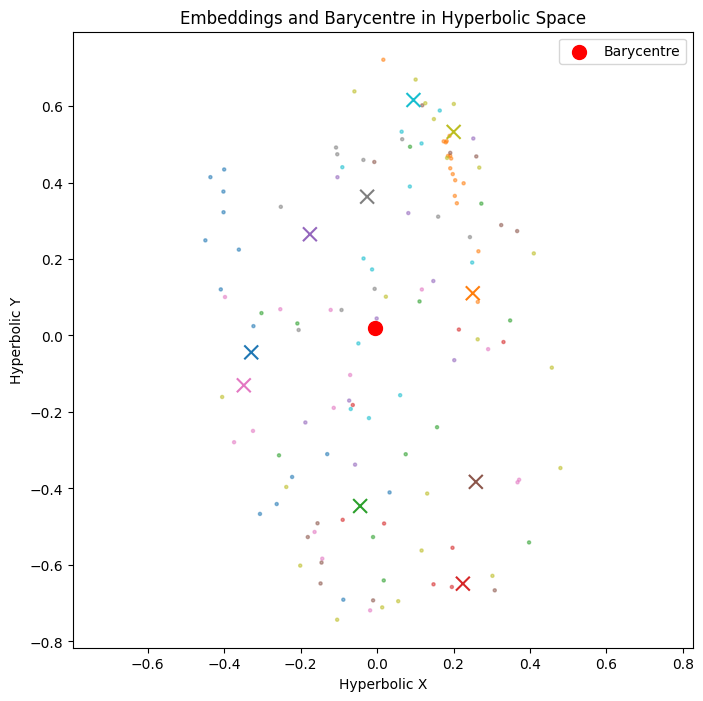

In [8]:
# we would like to compute the barycentre of the embeddings and use this to center the embeddings
with torch.no_grad():
    train_embeddings = emb(train_images).cpu().numpy()
    cluster_embeddings = emb(cluster_images).cpu().numpy()
    barycentre = emb.barycentre(train_images, max_iter=500, step_size=0.1)

plt.figure(figsize=(8, 8))
plt.scatter(train_embeddings[:, 0], train_embeddings[:, 1], c=train_labels.cpu().numpy(), s=5, alpha=0.5, cmap='tab10')
plt.scatter(cluster_embeddings[:, 0], cluster_embeddings[:, 1], c=cluster_labels.cpu().numpy(), marker='x', s=100, cmap='tab10')
plt.scatter(barycentre[0].item(), barycentre[1].item(), color='red', marker='o', s=100, label='Barycentre')
plt.title("Embeddings and Barycentre in Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.legend()
plt.savefig(os.path.join(results_folder,"emb_final.png"))
plt.show()  

In [9]:
# translate origin with isometr
# check that distances are preserved I: compute old distances
with torch.no_grad():
    dist_emb = emb.distance(cluster_images[1:], cluster_images[:-1])

# update origin
emb.set_origin(barycentre)
# emb.origin = None  # reset origin to default (0,0) - should give same distances as before since we are using isometries
# check that distances are preserved II: compute new distances
with torch.no_grad():
    dist_emb_centered = emb.distance(cluster_images[1:], cluster_images[:-1])

print("Pairwise distance matrix in embedding space between cluster centers:")
print((dist_emb - dist_emb_centered).abs().max())  # should be close to zero
assert torch.allclose(dist_emb, dist_emb_centered, atol=1e-6), "Distances are not preserved after centering!"

Pairwise distance matrix in embedding space between cluster centers:
tensor(3.1832e-12)


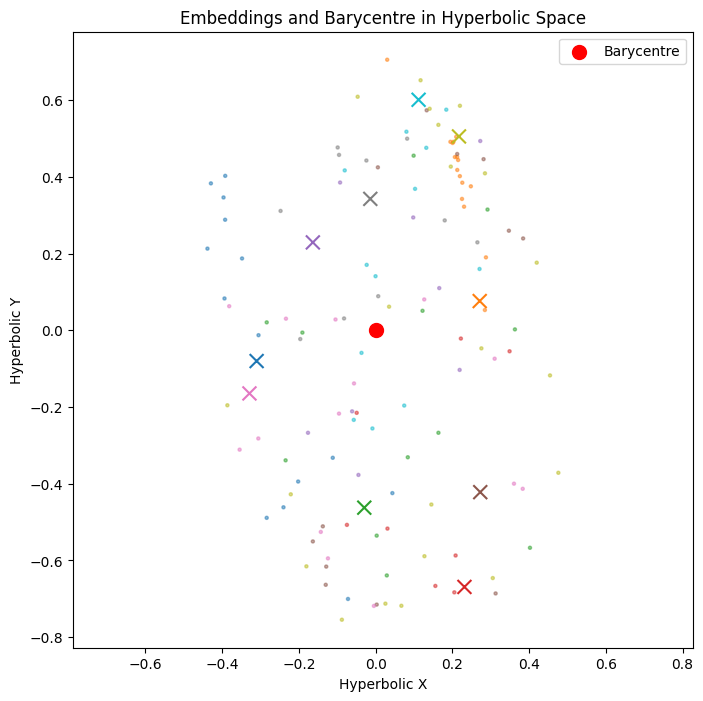

Distance between barycentres before and after centering:
9.851211429614319e-07


In [10]:
# we would like to compute the barycentre of the embeddings and use this to center the embeddings
with torch.no_grad():
    train_embeddings_centered = emb(train_images).cpu().numpy()
    cluster_embeddings_centered = emb(cluster_images).cpu().numpy()
    barycentre_centered = emb.barycentre(train_images, max_iter=500, step_size=0.1)

plt.figure(figsize=(8, 8))
plt.scatter(train_embeddings_centered[:, 0], train_embeddings_centered[:, 1], c=train_labels.cpu().numpy(), s=5, alpha=0.5, cmap='tab10')
plt.scatter(cluster_embeddings_centered[:, 0], cluster_embeddings_centered[:, 1], c=cluster_labels.cpu().numpy(), marker='x', s=100, cmap='tab10')
plt.scatter(barycentre_centered[0].item(), barycentre_centered[1].item(), color='red', marker='o', s=100, label='Barycentre')
plt.title("Embeddings and Barycentre in Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.legend()
plt.savefig(os.path.join(results_folder,"emb_final_centered.png"))
plt.show()  

# check difference between barycentres
print("Distance between barycentres before and after centering:")
translated_barycentre = emb.translate(barycentre, barycentre)
print((translated_barycentre - barycentre_centered).norm().item())  # should be close to zero

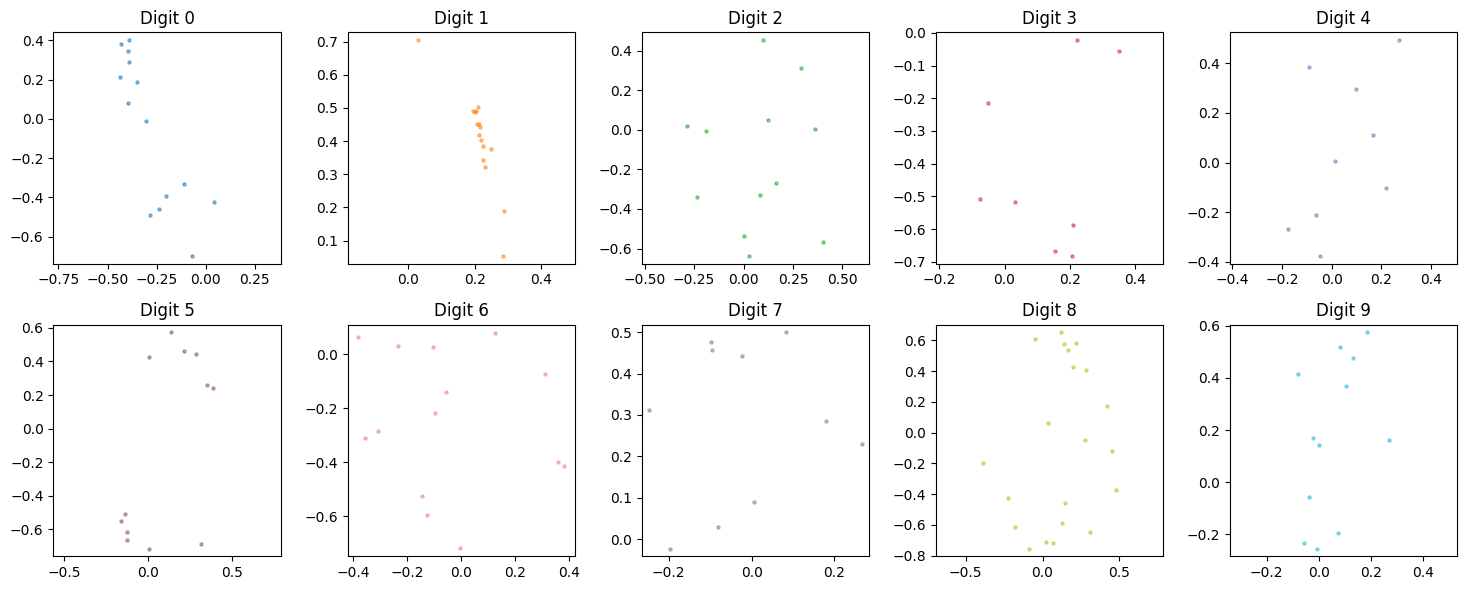

In [11]:
# make 10 plots for embeddings of each digit class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for digit in range(10):
    digit_indices = (train_labels == digit).nonzero(as_tuple=True)[0]
    digit_embeddings = train_embeddings_centered[digit_indices]
    axes[digit].scatter(digit_embeddings[:, 0], digit_embeddings[:, 1], s=5, alpha=0.5, color=f'C{digit}')
    axes[digit].set_title(f"Digit {digit}")
    axes[digit].axis('equal')
    # axes[digit].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"emb_final_centered_digits.png"))
plt.show()

### Stage 2: Learn an Embedding-informed Diffeomorphic Decoder ###

In [12]:
# construct normalizing flow model
class SimpleTransformImageDiffeomorphism(TransformImageDiffeomorphism):
    def __init__(self, in_channels, height, width, kernel_size, hidden_channels, n_flows):
        super(SimpleTransformImageDiffeomorphism, self).__init__(in_channels, height, width, self.create_transform(in_channels, height, width, kernel_size, hidden_channels, n_flows))

    def create_transform(self, in_channels, height, width, kernel_size, hidden_channels, n_flows):
        transforms_list = []
        for i in range(n_flows):
            transforms_list.append(ActNorm(features=in_channels))
            transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=i))
            transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=i+1))
            transforms_list.append(SimpleTanh2DParityConvImageTransform(in_channels, height, width, hidden_channels=hidden_channels, kernel_size=kernel_size, parity=i))
        transforms_list.append(ActNorm(features=in_channels))
        transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=n_flows))
        transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=n_flows+1))
        transforms_list.append(ToVecImageTransform(in_channels, height, width))
        # structured linear here to map to latent space of dimension latent_dim
        transform = transforms.CompositeTransform(transforms_list)
        return transform
    
# instantiate flow model
in_channels = phase_2_cfg["in_channels"]
height = size
width = size
kernel_size = phase_2_cfg["kernel_size"]
hidden_channels = phase_2_cfg["hidden_channels"]
n_flows = phase_2_cfg["n_flows"]

diffeo_decoder_trainer = DiffeomorphicDecoderTraining(
    emb,
    SimpleTransformImageDiffeomorphism(
        in_channels,
        height,
        width,
        kernel_size,
        hidden_channels,
        n_flows,
    ),
    reg_param=phase_2_cfg["reg_param"],
    sigma=sigma,
    lr=phase_2_cfg["learning_rate"],
)

In [13]:
# construct train loop
def phase_2_train(trainer, train_loader, save_dir, n_epochs, start_epoch=0):
    best_loss = float('inf')
    for epoch in range(start_epoch, n_epochs):
        epoch_loss = 0.0
        for (x, _), _ in tqdm(train_loader):
            loss = trainer.train_step(x)
            epoch_loss += loss * x.size(0)
        epoch_loss /= len(train_pair_dataset)
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss:.6f}")

        # Save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': trainer.phi.state_dict(),
            'optimizer_state_dict': trainer.optimizer.state_dict(),
            'loss': epoch_loss,
            'best_loss': best_loss,
        }
        
        torch.save(checkpoint, os.path.join(save_dir, f'epoch_{epoch+1}_model.pth'))

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(checkpoint, os.path.join(save_dir, 'best_model.pth'))

    print("Training completed. Best model saved with loss:", best_loss)

In [14]:
# train or load model for phase 2
checkpoint_dir = os.path.join(results_folder, phase_2_cfg["checkpoint_subdir"])
os.makedirs(checkpoint_dir, exist_ok=True)

if phase_2_training:
    start_epoch = 0
    latest_checkpoint = max(
        glob.glob(os.path.join(checkpoint_dir, "epoch_*_model.pth")),
        default=None,
        key=os.path.getctime,
    )

    if latest_checkpoint:
        print(f"Resuming training from {latest_checkpoint}")
        checkpoint = torch.load(latest_checkpoint)
        diffeo_decoder_trainer.phi.load_state_dict(checkpoint["model_state_dict"])
        diffeo_decoder_trainer.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        start_epoch = checkpoint["epoch"] + 1

    phase_2_train(
        diffeo_decoder_trainer,
        train_loader,
        save_dir=checkpoint_dir,
        n_epochs=phase_2_cfg["num_epochs"],
        start_epoch=start_epoch,
    )
else:
    best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
    checkpoint = torch.load(best_model_path, map_location=device)
    diffeo_decoder_trainer.phi.load_state_dict(checkpoint["model_state_dict"])

phi = diffeo_decoder_trainer.phi

100%|██████████| 375/375 [00:35<00:00, 10.65it/s]


Epoch 1/50, Loss: 1.576701


100%|██████████| 375/375 [00:34<00:00, 10.84it/s]


Epoch 2/50, Loss: 1.117285


100%|██████████| 375/375 [00:34<00:00, 10.83it/s]


...

Epoch 48/50, Loss: 0.549462


100%|██████████| 375/375 [00:32<00:00, 11.61it/s]


Epoch 49/50, Loss: 0.553841


100%|██████████| 375/375 [00:32<00:00, 11.63it/s]

Epoch 50/50, Loss: 0.547745
Training completed. Best model saved with loss: 0.547745255977709


In [15]:
# construct manifold from learned diffeomorphism
phi_manifold = StandardPullbackImageEuclidean(phi)
# construct iso_manifold 
# iso_manifold = l2IsometrizedImageEuclidean(manifold)

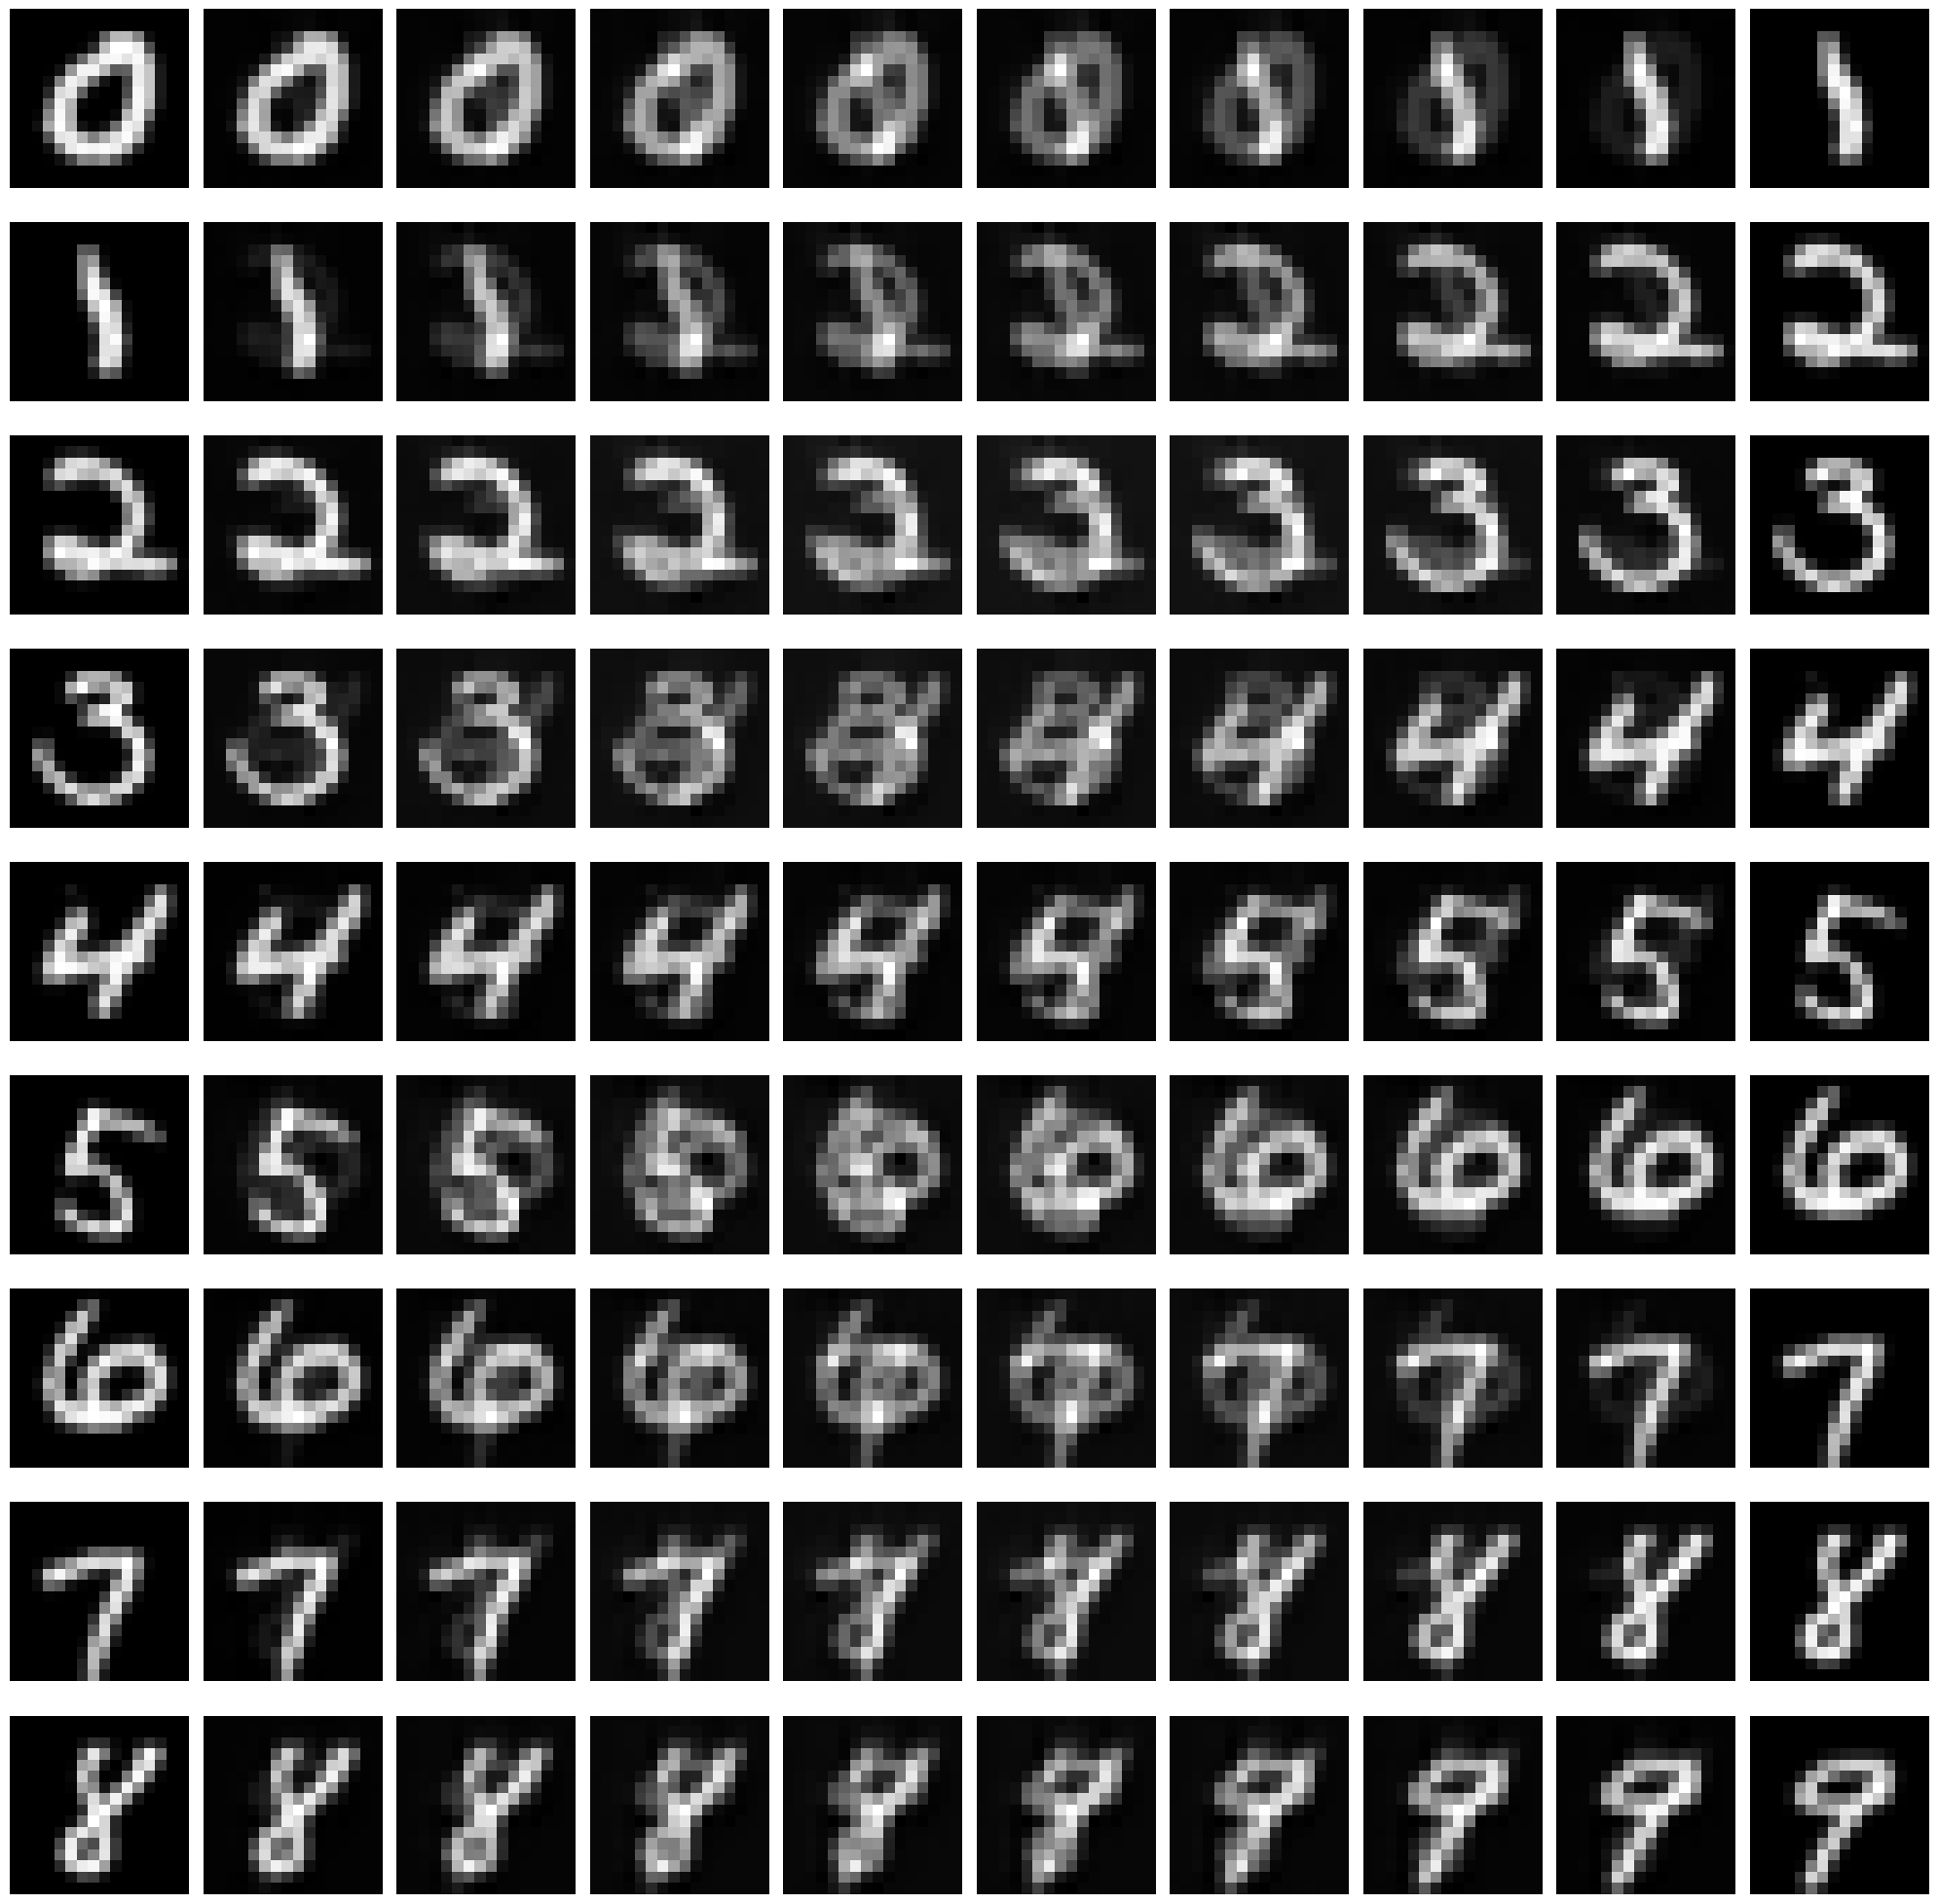

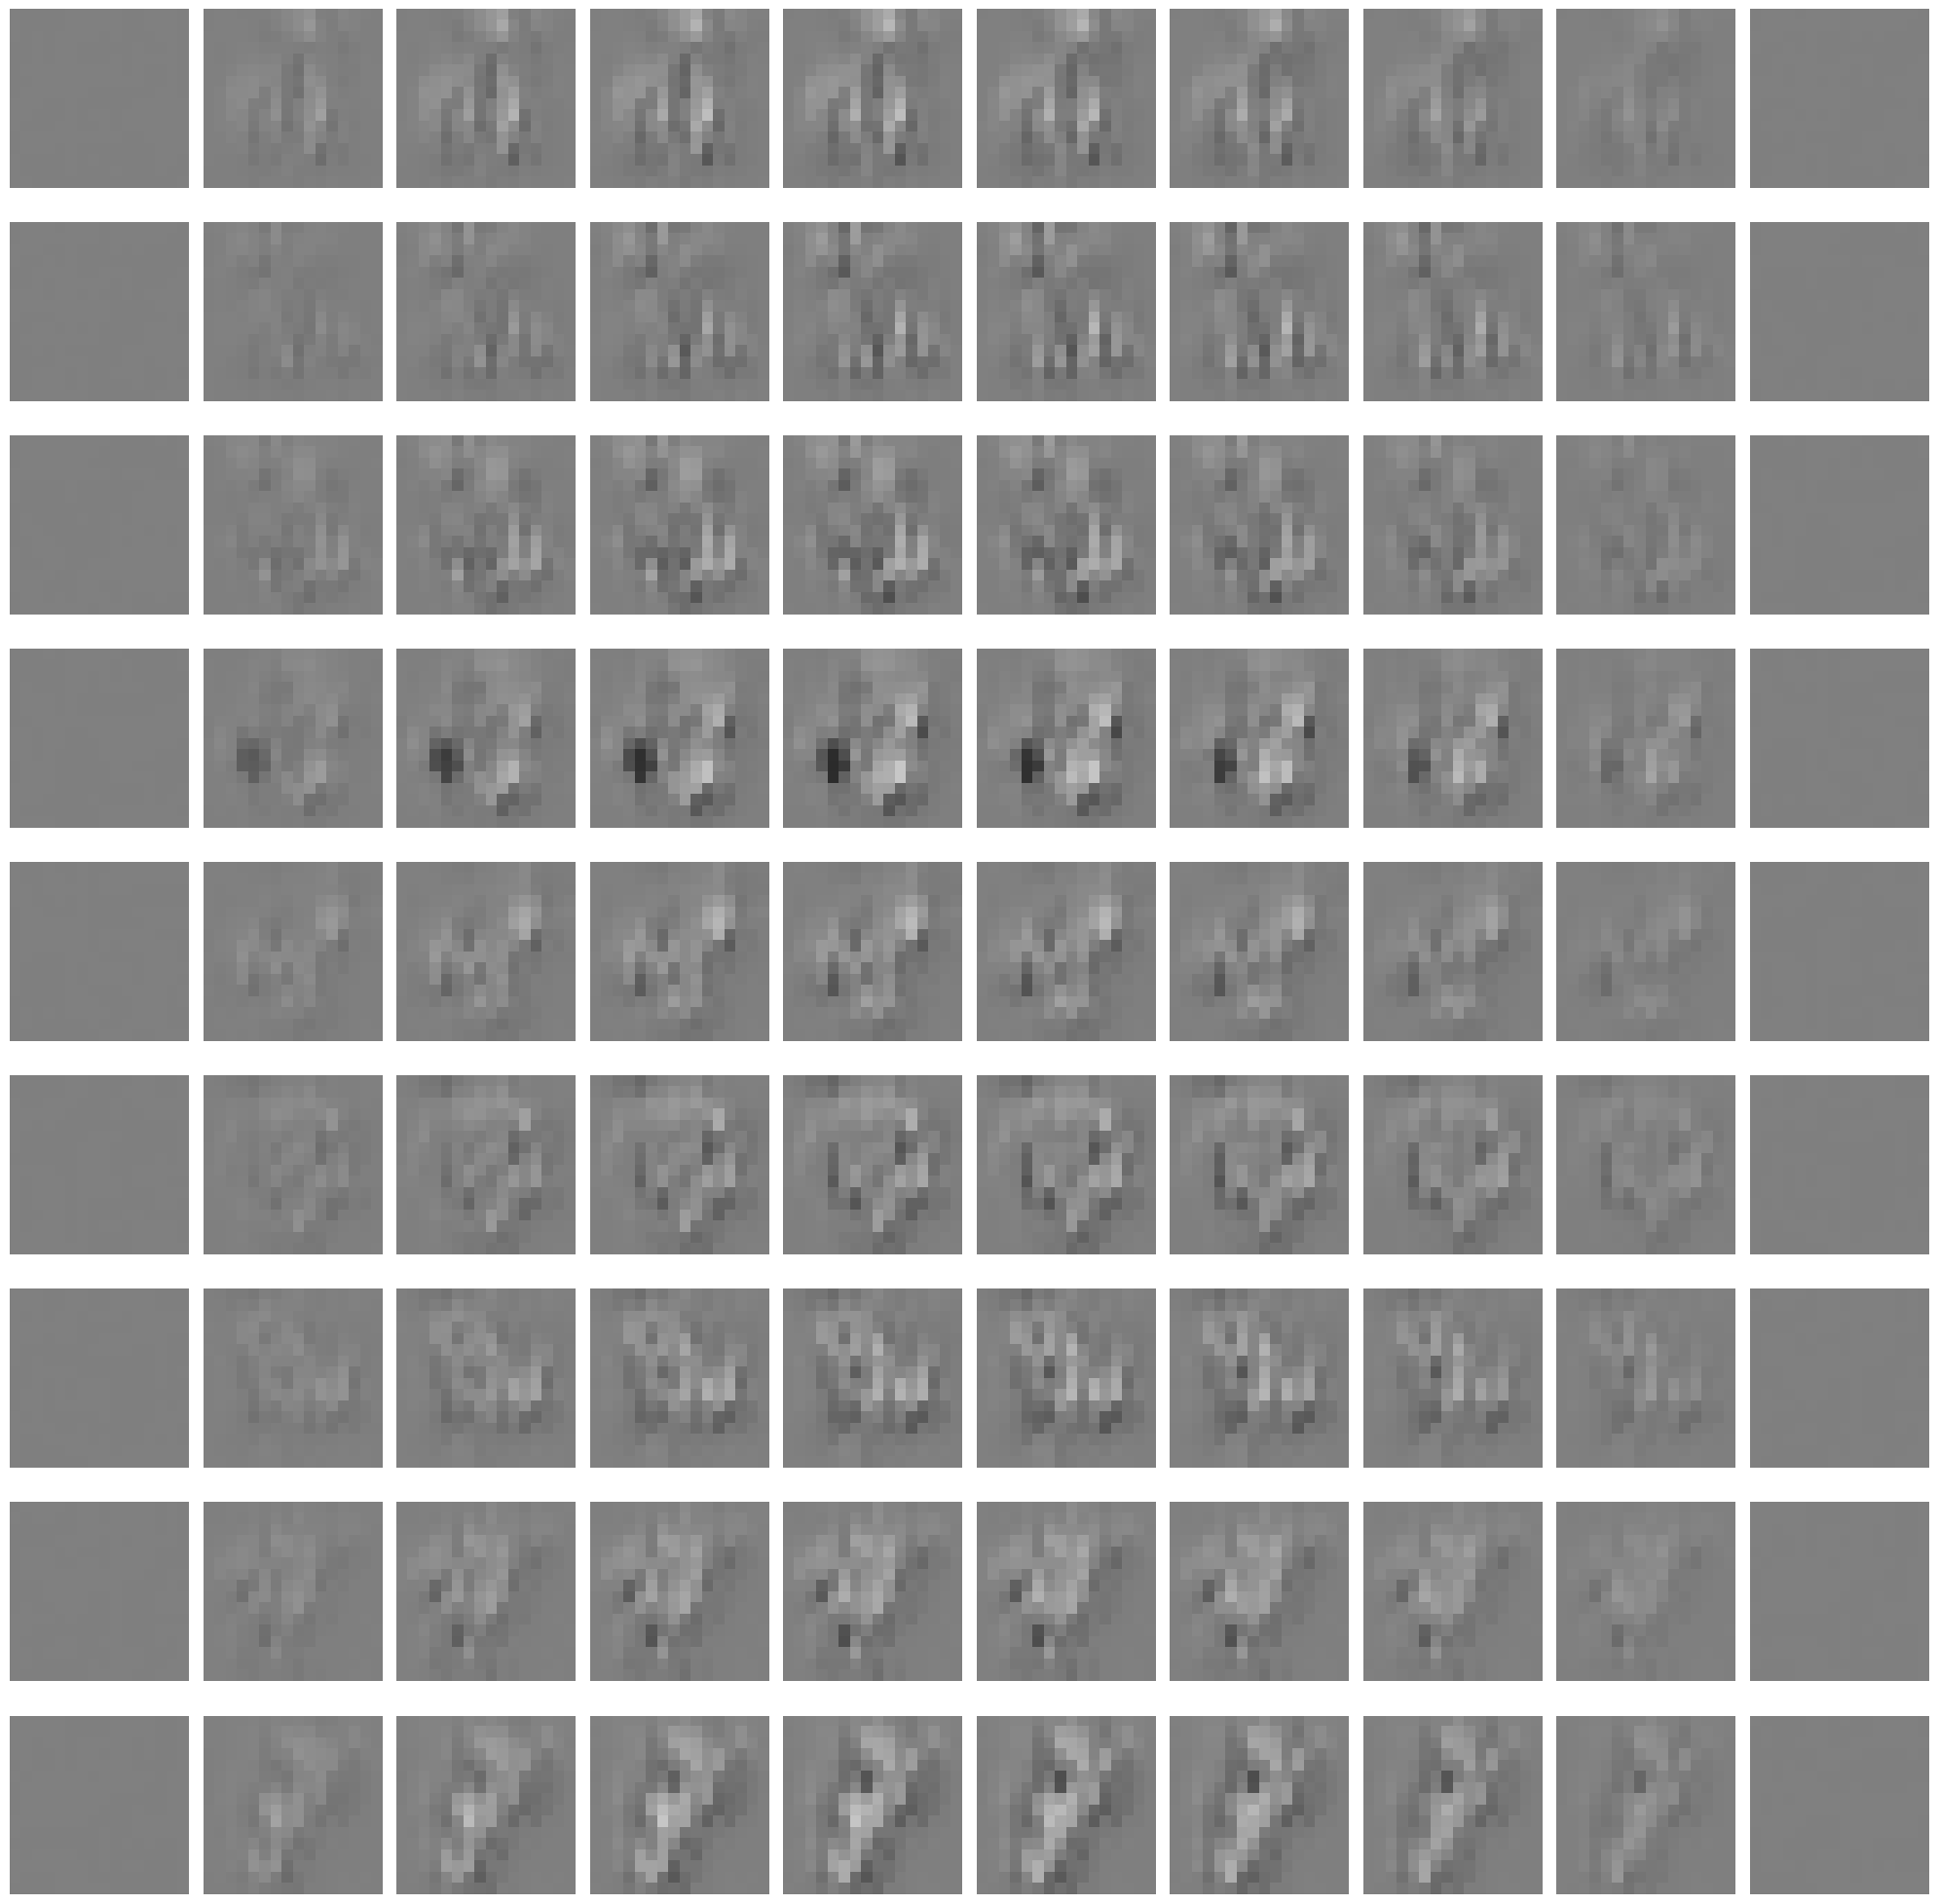

In [19]:
# compute geodesics between all pairs of points
K = 10
t = torch.linspace(0, 1, steps=K)
with torch.no_grad():
    geodesics = phi_manifold.geodesic(cluster_images[None], cluster_images[None], t)

# linear interpolation in pixel space for comparison
interpolations = []
for i in range(10-1):
    start = cluster_images[i]
    end = cluster_images[i+1]
    interp = torch.stack([start * (1 - alpha) + end * alpha for alpha in t], dim=0)
    interpolations.append(interp)
interpolations = torch.stack(interpolations, dim=0)  # shape: [9, K, 1, H, W]

# plot geodesics
# plot cluster images
fig, axes = plt.subplots(9, K, figsize=(int(K / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(K):
        axes[i*K + k].imshow(geodesics[0, i, i+1, k, 0], cmap='gray')
        axes[i*K + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data_geodesics.png"))
plt.show()

# plot difference with interpolations
fig, axes = plt.subplots(9, K, figsize=(int(K / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(K): # have same color scale for all plots
        axes[i*K + k].imshow(geodesics[0, i, i+1, k, 0] - interpolations[i, k, 0], cmap='gray', vmin=-0.5, vmax=0.5)
        axes[i*K + k].axis('off')  
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data_interpolations.png"))
plt.show()